# HomeWork12

### Импорт библиотек и настройка окружения

In [1]:
# Импорт библиотек
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

# Фиксируем seed для воспроизводимости
SEED = 47

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

Устройство: cpu


### Загрузка и первичный анализ данных

Число наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 — 2025-06-29 23:00:00

Пропуски по колонкам:
date      0
target    0
dtype: int64


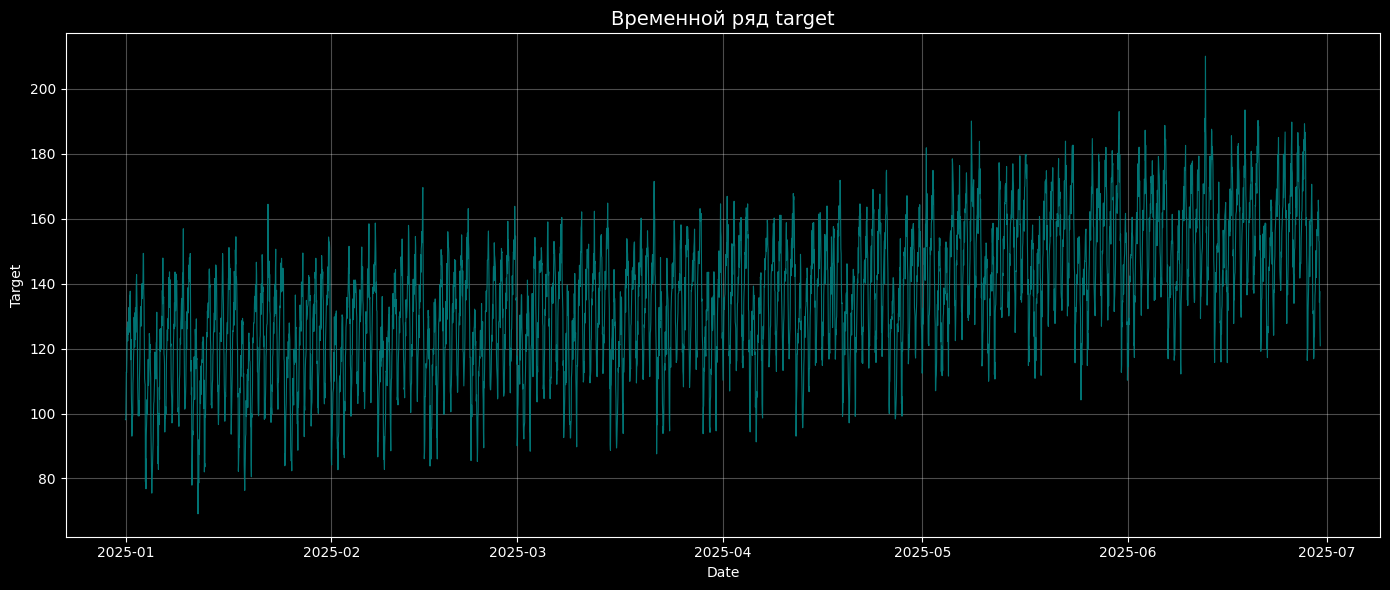

In [2]:
# Загрузка данных из CSV
df = pd.read_csv("S12-hw-dataset.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print("Число наблюдений:", len(df))
print("Диапазон дат:", df["date"].min(), "—", df["date"].max())

print("\nПропуски по колонкам:")
print(df.isna().sum())

# Визуализация исходного временного ряда
plt.figure(figsize=(14, 6))
plt.plot(df["date"], df["target"], linewidth=0.8, color='teal', alpha=0.9)
plt.title("Временной ряд target", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Target")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Анализ ряда:**
- Наблюдается явный восходящий тренд. Средний уровень последовательно растёт.
- Присутствуют регулярные суточные колебания (сезонность).
- Отдельные выбросы не выглядят экстремальными.
- Ряд нестационарен (тренд + сезонность).

### Temporal split

**Почему random split недопустим?**  
Для временных рядов использование случайного разбиения (shuffle=True) приводит к "утечке данных" (data leakage) — модель получает доступ к будущим точкам во время обучения. Это искажает оценку реальной прогностической способности. Поэтому используется только хронологическое разбиение.

Train:
2025-01-01 00:00:00 — 2025-04-27 23:00:00 | size: 2808

Validation:
2025-04-28 00:00:00 — 2025-05-29 11:00:00 | size: 756

Test:
2025-05-29 12:00:00 — 2025-06-29 23:00:00 | size: 756


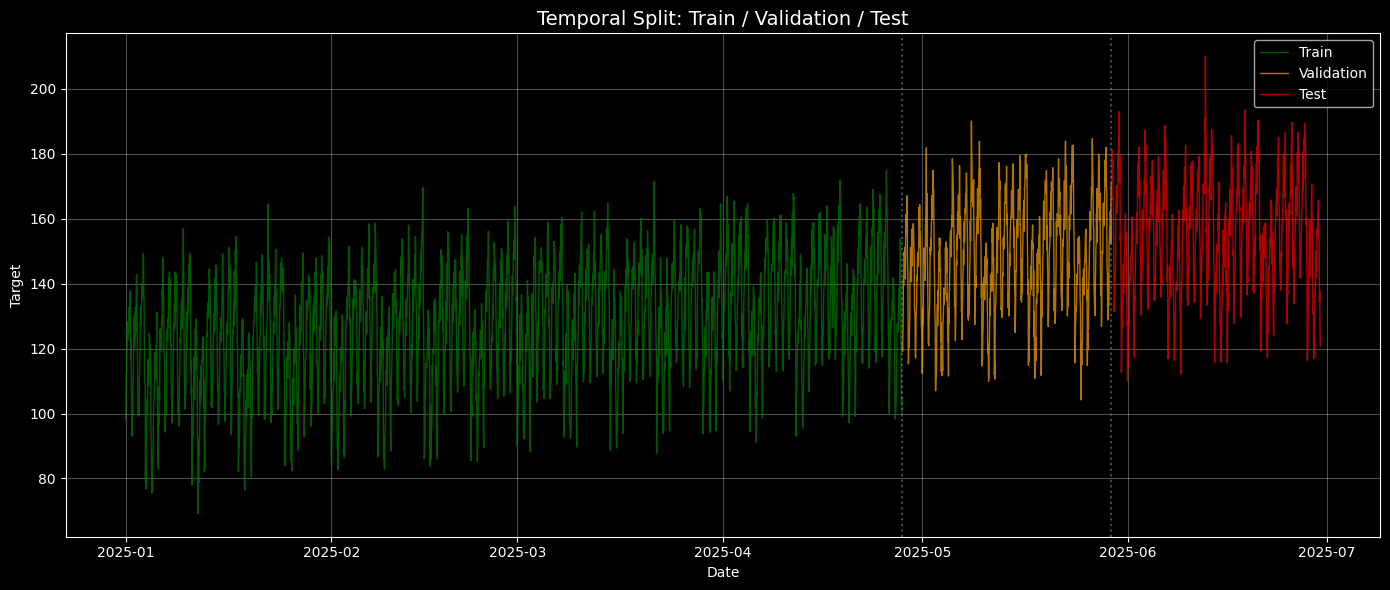

In [3]:
# Доли: 65% train, 17.5% validation, 17.5% test
n = len(df)
train_end = int(n * 0.65)
val_end = int(n * 0.825)

train_df = df.iloc[:train_end].copy()
val_df = df.iloc[train_end:val_end].copy()
test_df = df.iloc[val_end:].copy()

print("Train:")
print(train_df["date"].min(), "—", train_df["date"].max(), "| size:", len(train_df))
print("\nValidation:")
print(val_df["date"].min(), "—", val_df["date"].max(), "| size:", len(val_df))
print("\nTest:")
print(test_df["date"].min(), "—", test_df["date"].max(), "| size:", len(test_df))

# Визуализация разбиения с разными цветами
plt.figure(figsize=(14, 6))
plt.plot(train_df["date"], train_df["target"], label="Train", linewidth=1, color='green', alpha=0.7)
plt.plot(val_df["date"], val_df["target"], label="Validation", linewidth=1, color='orange', alpha=0.7)
plt.plot(test_df["date"], test_df["target"], label="Test", linewidth=1, color='red', alpha=0.7)
plt.axvline(x=train_df["date"].max(), color='gray', linestyle=':', alpha=0.6)
plt.axvline(x=val_df["date"].max(), color='gray', linestyle=':', alpha=0.6)
plt.title("Temporal Split: Train / Validation / Test", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Target")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("artifacts/figures/series_split.png", dpi=150)
plt.show()

Случайное разделение (random split) перемешивает данные из разных временных периодов, что вызывает утечку информации из будущего. Это приводит к завышенной оценке качества модели и искажает причинную структуру временных рядов. Поэтому для анализа используется только temporal split, а random split не подходит.

### Построение признаков для baseline-моделей

In [4]:
# Создание признаков на основе исходного датафрейма
df_features = df.copy()

# Лаговые признаки
df_features["lag_1"] = df_features["target"].shift(1)
df_features["lag_7"] = df_features["target"].shift(7)
df_features["lag_14"] = df_features["target"].shift(14)

# Скользящие статистики (окно 7)
df_features["rolling_mean_7"] = df_features["target"].shift(1).rolling(window=7).mean()
df_features["rolling_std_7"] = df_features["target"].shift(1).rolling(window=7).std()

# Календарные признаки
df_features["day_of_week"] = df_features["date"].dt.dayofweek
df_features["month"] = df_features["date"].dt.month
df_features["hour"] = df_features["date"].dt.hour

# Удаление строки с NaN, появившиеся из-за сдвигов
df_features = df_features.dropna().reset_index(drop=True)

print("Признаки:")
print(df_features.columns.tolist())
print("\nРазмер после удаления NaN ->", len(df_features))

# temporal split с учётом удалённых строк
n = len(df_features)
train_end = int(n * 0.7)
val_end = int(n * 0.85)

train_features = df_features.iloc[:train_end].copy()
val_features = df_features.iloc[train_end:val_end].copy()
test_features = df_features.iloc[val_end:].copy()

print("\nРазмеры после split:")
print("Train ->", len(train_features))
print("Validation ->", len(val_features))
print("Test ->", len(test_features))

Признаки:
['date', 'target', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_std_7', 'day_of_week', 'month', 'hour']

Размер после удаления NaN -> 4306

Размеры после split:
Train -> 3014
Validation -> 646
Test -> 646


### Подготовка оконного представления для GRU

In [5]:
# Параметры окна
window_size = 36  # 36 часов
series = df["target"].values.astype("float32")

n = len(series)
train_end = int(n * 0.65)
val_end = int(n * 0.825)

train_series = series[:train_end]
val_series = series[train_end:val_end]
test_series = series[val_end:]

# Масштабирование (fit только на train)
scaler = StandardScaler()
train_series_scaled = scaler.fit_transform(train_series.reshape(-1, 1)).flatten()
val_series_scaled = scaler.transform(val_series.reshape(-1, 1)).flatten()
test_series_scaled = scaler.transform(test_series.reshape(-1, 1)).flatten()

print("Масштабирование выполнено (fit только на train)")
print("Train mean после scaling ->", train_series_scaled.mean())
print("Train std после scaling ->", train_series_scaled.std())

def create_windows(series, window):
    X = []
    y = []
    for i in range(len(series) - window):
        X.append(series[i:i+window])
        y.append(series[i+window])
    return np.array(X), np.array(y)

X_train_gru, y_train_gru = create_windows(train_series_scaled, window_size)
X_val_gru, y_val_gru = create_windows(val_series_scaled, window_size)
X_test_gru, y_test_gru = create_windows(test_series_scaled, window_size)

print("\nФормы данных для GRU:")
print("X_train ->", X_train_gru.shape, "| y_train ->", y_train_gru.shape)
print("X_val ->", X_val_gru.shape, "| y_val ->", y_val_gru.shape)
print("X_test ->", X_test_gru.shape, "| y_test ->", y_test_gru.shape)

# Dataset и DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

batch_size = 96
train_dataset = TimeSeriesDataset(X_train_gru, y_train_gru)
val_dataset = TimeSeriesDataset(X_val_gru, y_val_gru)
test_dataset = TimeSeriesDataset(X_test_gru, y_test_gru)

# shuffle=True допустимо для обучения GRU, так как окна уже сформированы
# без нарушения временного порядка (история не перемешивается)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("\nDataLoader создан:")
print("Train batches ->", len(train_loader))
print("Val batches ->", len(val_loader))
print("Test batches ->", len(test_loader))

Масштабирование выполнено (fit только на train)
Train mean после scaling -> -9.781275e-08
Train std после scaling -> 1.0

Формы данных для GRU:
X_train -> (2772, 36) | y_train -> (2772,)
X_val -> (720, 36) | y_val -> (720,)
X_test -> (720, 36) | y_test -> (720,)

DataLoader создан:
Train batches -> 29
Val batches -> 8
Test batches -> 8


### Определение модели GRU и вспомогательных функций

In [6]:
# Модель GRU с одним слоем
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out.squeeze()

# Функция обучения одной эпохи
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for X, y in loader:
        X = X.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        pred = model(X)
        loss = criterion(pred, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * X.size(0)
    return total_loss / len(loader.dataset)

# Функция оценки на валидации/тесте
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    preds = []
    targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            y = y.to(device)
            pred = model(X)
            loss = criterion(pred, y)
            total_loss += loss.item() * X.size(0)
            preds.append(pred.cpu().numpy())
            targets.append(y.cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    mse = ((preds - targets) ** 2).mean()
    mae = np.abs(preds - targets).mean()
    return total_loss / len(loader.dataset), mse, mae

# Расчёт метрик MAE, RMSE, MAPE
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mask = y_true != 0
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
    return mae, rmse, mape

### Логирование результатов экспериментов

In [7]:
# Создаём папки для артефактов
os.makedirs("artifacts/figures", exist_ok=True)

In [8]:
experiment_results = []

def log_experiment(exp_id, model_name, val_true, val_pred,
                test_true=None, test_pred=None, window_size=None,
                features="", optimizer="", lr=0, epochs=0, notes="", log_test=False):
    val_mae, val_rmse, val_mape = calculate_metrics(val_true, val_pred)

    # Инициализируем тестовые метрики как None
    test_mae, test_rmse, test_mape = None, None, None
    if log_test and test_true is not None and test_pred is not None:
        test_mae, test_rmse, test_mape = calculate_metrics(test_true, test_pred)

    run = {
        "experiment_id": exp_id,
        "task": "forecasting",
        "dataset": "S12-hw-dataset",
        "seed": SEED,
        "split_summary": "65/17.5/17.5 (Temporal)",
        "window_size": window_size if window_size else "N/A",
        "horizon": 1,
        "model_summary": model_name,
        "features_summary": features,
        "scaler": "StandardScaler",
        "optimizer": optimizer if optimizer else "N/A",
        "lr": lr,
        "epochs_trained": epochs,
        "best_val_mae": val_mae,
        "best_val_rmse": val_rmse,
        "best_val_mape": val_mape,
        "test_mae": test_mae,
        "test_rmse": test_rmse,
        "test_mape": test_mape,
        "notes": notes
    }
    experiment_results.append(run)
    print(f"[{exp_id}] Val MAE -> {val_mae:.4f}, Test MAE -> {test_mae if test_mae else 'N/A'}")
    return val_mae

### Эксперименты

#### B1: Naive‑last (прогноз = последнее значение)

In [9]:
def naive_last_forecast(train, val, test):
    val_pred = np.roll(val, 1)
    val_pred[0] = train[-1]
    test_pred = np.roll(test, 1)
    test_pred[0] = val[-1]
    return val_pred, test_pred

val_pred_b1, test_pred_b1 = naive_last_forecast(train_series, val_series, test_series)
log_experiment("B1", "naive-last",
            val_true=val_series, val_pred=val_pred_b1,
            features="Last value (y_t-1)", lr=0.0,
            notes="Baseline -> y_t = y_{t-1}")

[B1] Val MAE -> 6.5203, Test MAE -> N/A


6.520330429077148

#### B2: Moving Average (окно 7)

In [10]:
def moving_average_forecast(train, val, test, window=7):
    val_pred = np.zeros_like(val)
    for i in range(len(val)):
        if i == 0:
            history = train[-window:]
        else:
            context = list(train[-window:]) + list(val[:i])
            history = context[-window:]
        val_pred[i] = np.mean(history)

    test_pred = np.zeros_like(test)
    for i in range(len(test)):
        if i == 0:
            history = val[-window:]
        else:
            context = list(val[-window:]) + list(test[:i])
            history = context[-window:]
        test_pred[i] = np.mean(history)
    return val_pred, test_pred

ma_window = 7
val_pred_b2, test_pred_b2 = moving_average_forecast(train_series, val_series, test_series, ma_window)

log_experiment("B2", f"Moving Average (w={ma_window})",
            val_true=val_series, val_pred=val_pred_b2,
            window_size=ma_window,
            features="Rolling mean (win=7)", lr=0.0,
            notes=f"Sliding window mean size {ma_window}")

[B2] Val MAE -> 12.6111, Test MAE -> N/A


12.611083030700684

#### B3: Ridge regression с лаговыми и календарными признаками

In [11]:
feature_cols = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7",
    "day_of_week", "month", "hour"
]

X_ridge = df_features[feature_cols].values
y_ridge = df_features["target"].values

n = len(df_features)
tr_idx = int(n * 0.65)
val_idx = int(n * 0.825)

X_train_ridge = X_ridge[:tr_idx]
X_val_ridge = X_ridge[tr_idx:val_idx]
X_test_ridge = X_ridge[val_idx:]

y_train_ridge = y_ridge[:tr_idx]
y_val_ridge = y_ridge[tr_idx:val_idx]
y_test_ridge = y_ridge[val_idx:]

# Масштабирование (fit только на train)
ridge_scaler = StandardScaler()
X_train_ridge_sc = ridge_scaler.fit_transform(X_train_ridge)
X_val_ridge_sc = ridge_scaler.transform(X_val_ridge)
X_test_ridge_sc = ridge_scaler.transform(X_test_ridge)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_ridge_sc, y_train_ridge)

val_pred_b3 = ridge_model.predict(X_val_ridge_sc)
test_pred_b3 = ridge_model.predict(X_test_ridge_sc)

log_experiment("B3", "Ridge Regression",
            val_true=y_val_ridge, val_pred=val_pred_b3,
            features="Lags(1,7,14), Rolling(mean,std,win=7), Calendar(h,dow,m)",
            optimizer="Closed-form",
            lr=1.0,  # alpha для Ridge
            notes="Linear model with engineered features")

[B3] Val MAE -> 5.8213, Test MAE -> N/A


5.821296582711407

#### R1: GRU (рекуррентная нейронная сеть)

In [12]:
hidden_size = 64
lr_gru = 2e-3   # скорость обучения
epochs_gru = 20

gru_model = GRUModel(input_size=1, hidden_size=hidden_size, num_layers=1).to(device)
optimizer_gru = optim.Adam(gru_model.parameters(), lr=lr_gru)
criterion = nn.MSELoss()

loss_history = []
mae_history = []

best_val_loss = float('inf')

for epoch in range(epochs_gru):
    train_loss = train_epoch(gru_model, train_loader, optimizer_gru, criterion, device)
    val_loss, _, val_mae = evaluate(gru_model, val_loader, criterion, device)

    loss_history.append(train_loss)
    mae_history.append(val_mae)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(gru_model.state_dict(), "artifacts/best_gru.pt")
        config = {
            "window_size": window_size,
            "hidden_size": hidden_size,
            "batch_size": batch_size,
            "learning_rate": lr_gru,
            "epochs": epochs_gru,
            "seed": SEED,
            "architecture": "GRU(1->64->1)",
            "scaler": "StandardScaler"
        }
        with open("artifacts/best_gru_config.json", "w") as f:
            json.dump(config, f, indent=4)

    print(f"Epoch {epoch+1}/{epochs_gru} | train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | val_mae={val_mae:.4f}")

# Загрузка лучшей модели
gru_model.load_state_dict(torch.load("artifacts/best_gru.pt"))
gru_model.eval()

# Сбор предсказаний в масштабированном виде
val_preds_scaled = []
val_targets_scaled = []
test_preds_scaled = []
test_targets_scaled = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device)
        pred = gru_model(X)
        val_preds_scaled.append(pred.cpu().numpy())
        val_targets_scaled.append(y.numpy())
    for X, y in test_loader:
        X = X.to(device)
        pred = gru_model(X)
        test_preds_scaled.append(pred.cpu().numpy())
        test_targets_scaled.append(y.numpy())

val_preds_scaled = np.concatenate(val_preds_scaled)
val_targets_scaled = np.concatenate(val_targets_scaled)
test_preds_scaled = np.concatenate(test_preds_scaled)
test_targets_scaled = np.concatenate(test_targets_scaled)

# Обратное масштабирование
val_pred_r1 = scaler.inverse_transform(val_preds_scaled.reshape(-1, 1)).flatten()
val_true_r1 = scaler.inverse_transform(val_targets_scaled.reshape(-1, 1)).flatten()
test_pred_r1 = scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).flatten()
test_true_r1 = scaler.inverse_transform(test_targets_scaled.reshape(-1, 1)).flatten()

# Добавляем GRU в таблицу экспериментов (без тестовых метрик)
log_experiment("R1", "GRU Neural Network", val_true_r1, val_pred_r1,
               window_size=window_size, features="Raw scaled sequence",
               optimizer="Adam", lr=lr_gru, epochs=epochs_gru,
               notes=f"Hidden size {hidden_size}, Best Val Loss {best_val_loss:.4f}",
               log_test=False)

Epoch 1/20 | train_loss=0.6026 | val_loss=0.4391 | val_mae=0.5503
Epoch 2/20 | train_loss=0.1971 | val_loss=0.1913 | val_mae=0.3525
Epoch 3/20 | train_loss=0.1683 | val_loss=0.2463 | val_mae=0.4018
Epoch 4/20 | train_loss=0.1593 | val_loss=0.2048 | val_mae=0.3658
Epoch 5/20 | train_loss=0.1543 | val_loss=0.2078 | val_mae=0.3682
Epoch 6/20 | train_loss=0.1502 | val_loss=0.2504 | val_mae=0.4055
Epoch 7/20 | train_loss=0.1493 | val_loss=0.2161 | val_mae=0.3752
Epoch 8/20 | train_loss=0.1452 | val_loss=0.2128 | val_mae=0.3706
Epoch 9/20 | train_loss=0.1416 | val_loss=0.2057 | val_mae=0.3619
Epoch 10/20 | train_loss=0.1210 | val_loss=0.1563 | val_mae=0.3099
Epoch 11/20 | train_loss=0.1107 | val_loss=0.1488 | val_mae=0.3026
Epoch 12/20 | train_loss=0.1081 | val_loss=0.1442 | val_mae=0.2960
Epoch 13/20 | train_loss=0.1082 | val_loss=0.1354 | val_mae=0.2813
Epoch 14/20 | train_loss=0.1063 | val_loss=0.1697 | val_mae=0.3231
Epoch 15/20 | train_loss=0.1037 | val_loss=0.1584 | val_mae=0.3117
Epoc

5.108063220977783

### Сравнение моделей и выбор лучшей

In [13]:
# Сначала все эксперименты уже добавлены в experiment_results (B1, B2, B3, R1 без теста)
df_results = pd.DataFrame(experiment_results)
print("Все эксперименты (без тестовых метрик):")
print(df_results[['experiment_id', 'best_val_mae']].sort_values('best_val_mae'))

best_row = df_results.loc[df_results['best_val_mae'].idxmin()]
best_exp_id = best_row['experiment_id']
print(f"\nЛучшая модель по Validation MAE -> {best_exp_id}")

# Удаляем старую запись лучшей модели
experiment_results = [r for r in experiment_results if r['experiment_id'] != best_exp_id]

# Добавляем запись лучшей модели с тестовыми метриками
if best_exp_id == "B1":
    log_experiment(best_exp_id, "naive-last", val_series, val_pred_b1,
                   test_true=test_series, test_pred=test_pred_b1,
                   features="Last value (y_t-1)", lr=0.0, log_test=True)
elif best_exp_id == "B2":
    log_experiment(best_exp_id, f"Moving Average (w={ma_window})", val_series, val_pred_b2,
                   test_true=test_series, test_pred=test_pred_b2,
                   window_size=ma_window, features="Rolling mean (win=7)", lr=0.0, log_test=True)
elif best_exp_id == "B3":
    log_experiment(best_exp_id, "Ridge Regression", y_val_ridge, val_pred_b3,
                   test_true=y_test_ridge, test_pred=test_pred_b3,
                   features="Lags(1,7,14), Rolling(mean,std,win=7), Calendar(h,dow,m)",
                   optimizer="Closed-form", lr=1.0, log_test=True)
elif best_exp_id == "R1":
    log_experiment(best_exp_id, "GRU Neural Network", val_true_r1, val_pred_r1,
                   test_true=test_true_r1, test_pred=test_pred_r1,
                   window_size=window_size, features="Raw scaled sequence",
                   optimizer="Adam", lr=lr_gru, epochs=epochs_gru,
                   notes=f"Hidden size {hidden_size}, Best Val Loss {best_val_loss:.4f}",
                   log_test=True)
else:
    # fallback
    pass

# Сохраняем итоговую таблицу
df_results = pd.DataFrame(experiment_results)
df_results.to_csv("artifacts/runs.csv", index=False)
print("\nИтоговая таблица (с тестовыми метриками только для лучшей модели):")
print(df_results[['experiment_id', 'best_val_mae', 'test_mae']].sort_values('best_val_mae'))

Все эксперименты (без тестовых метрик):
  experiment_id  best_val_mae
3            R1      5.108063
2            B3      5.821297
0            B1      6.520330
1            B2     12.611083

Лучшая модель по Validation MAE -> R1
[R1] Val MAE -> 5.1081, Test MAE -> 5.489541053771973

Итоговая таблица (с тестовыми метриками только для лучшей модели):
  experiment_id  best_val_mae  test_mae
3            R1      5.108063  5.489541
2            B3      5.821297       NaN
0            B1      6.520330       NaN
1            B2     12.611083       NaN


### Визуализация результатов

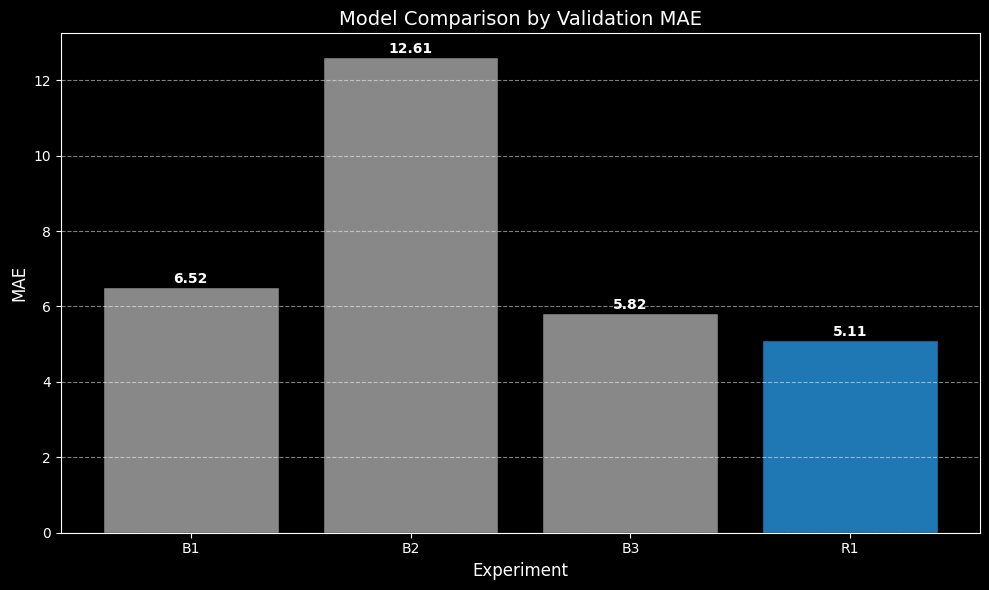

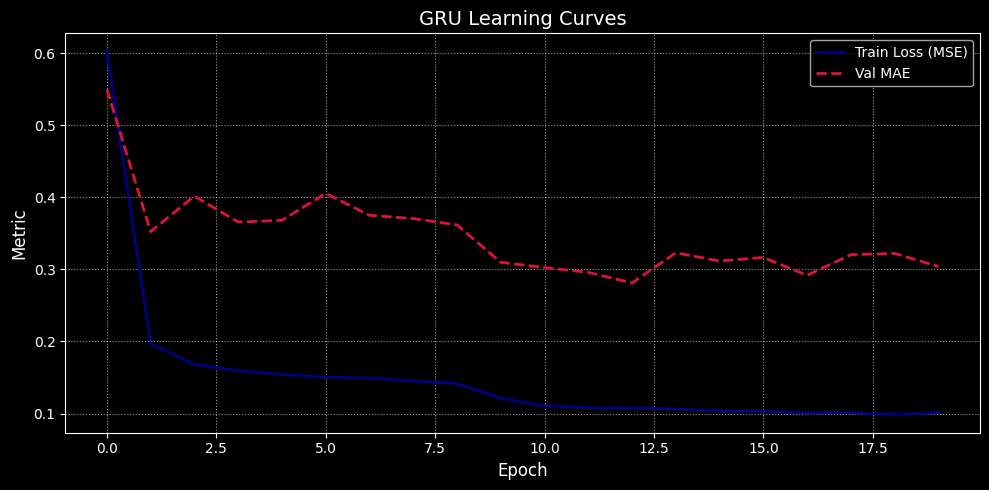

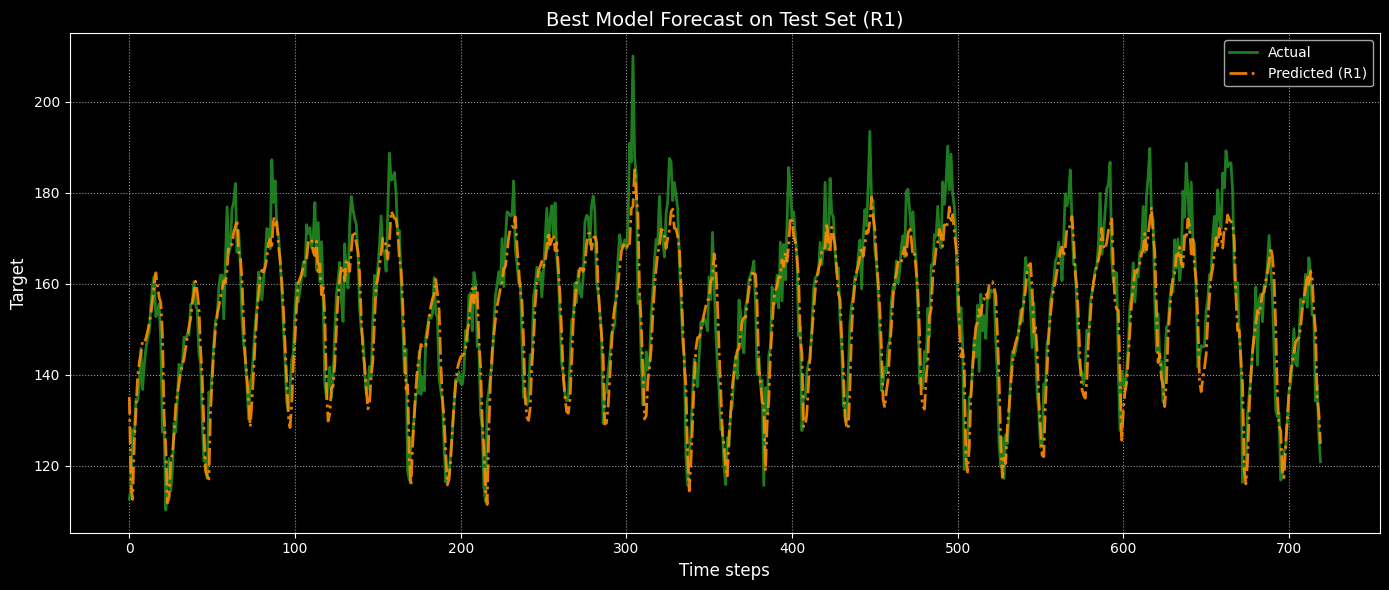

Графики сохранены


In [14]:
# График сравнения baseline моделей
plt.figure(figsize=(10, 6))
colors = ['#888888', '#888888', '#888888', '#1f77b4']
plt.bar(df_results['experiment_id'], df_results['best_val_mae'], color=colors, edgecolor='black', linewidth=1)
plt.title('Model Comparison by Validation MAE', fontsize=14)
plt.ylabel('MAE', fontsize=12)
plt.xlabel('Experiment', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(df_results['best_val_mae']):
    plt.text(i, v + 0.1, f'{v:.2f}', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('artifacts/figures/baselines_compare.png', dpi=150)
plt.show()

# Кривые обучения GRU
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Train Loss (MSE)', linewidth=2, color='navy', linestyle='-')
plt.plot(mae_history, label='Val MAE', linewidth=2, color='crimson', linestyle='--')
plt.title('GRU Learning Curves', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('artifacts/figures/gru_learning_curves.png', dpi=150)
plt.show()

# Прогноз лучшей модели на тестовой выборке
if best_exp_id == 'B1':
    y_pred_best = test_pred_b1
elif best_exp_id == 'B2':
    y_pred_best = test_pred_b2
elif best_exp_id == 'B3':
    y_pred_best = test_pred_b3
else:  # R1
    y_pred_best = test_pred_r1
    y_true_best = test_true_r1

plt.figure(figsize=(14, 6))
plt.plot(y_true_best, label='Actual', linewidth=2, color='forestgreen', alpha=0.9)
plt.plot(y_pred_best, label=f'Predicted ({best_exp_id})', linestyle='-.', linewidth=2, color='darkorange', alpha=0.9)
plt.title(f'Best Model Forecast on Test Set ({best_exp_id})', fontsize=14)
plt.xlabel('Time steps', fontsize=12)
plt.ylabel('Target', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('artifacts/figures/best_forecast_test.png', dpi=150)
plt.show()

print("Графики сохранены")